# Vir's Quant Project — SMA Crossover Backtester  

This project implements a **Simple Moving Average (SMA) Crossover Strategy** using **Backtrader** and **yfinance**.  
It is designed as a starting point for quant research and can be extended with additional filters, risk controls, and portfolio-level logic.

---

## ✨ Features
- **Core Strategy:**  
  - Buy when `SMA_fast > SMA_slow`  
  - Sell when `SMA_fast < SMA_slow`
- **Optional Filters:**  
  - **RSI**: Enter only if RSI < threshold, exit only if RSI > threshold  
  - **MACD**: Confirm trend direction before entering/exiting
- **Risk Controls:**  
  - Optional **trailing stop** (percentage-based)
- **Portfolio Support:**  
  - Backtest one or multiple tickers simultaneously  
  - Produces both per-ticker equity curves and an equal-weight basket curve
- **Performance Metrics:**  
  - Cumulative Return  
  - Maximum Drawdown  
  - Sharpe Ratio (daily)  

---

## 🧰 Tech Stack
- **Python**  
- **Backtrader** — Backtesting engine  
- **yfinance** — Historical data API  
- **pandas, numpy** — Data handling  
- **matplotlib** — Visualization  

---



========== Backtest Summary ==========
       Cumulative Return Max Drawdown Sharpe (daily)
Ticker                                              
MSFT               1.67%        0.99%           0.03
AAPL               1.36%        0.63%           0.04


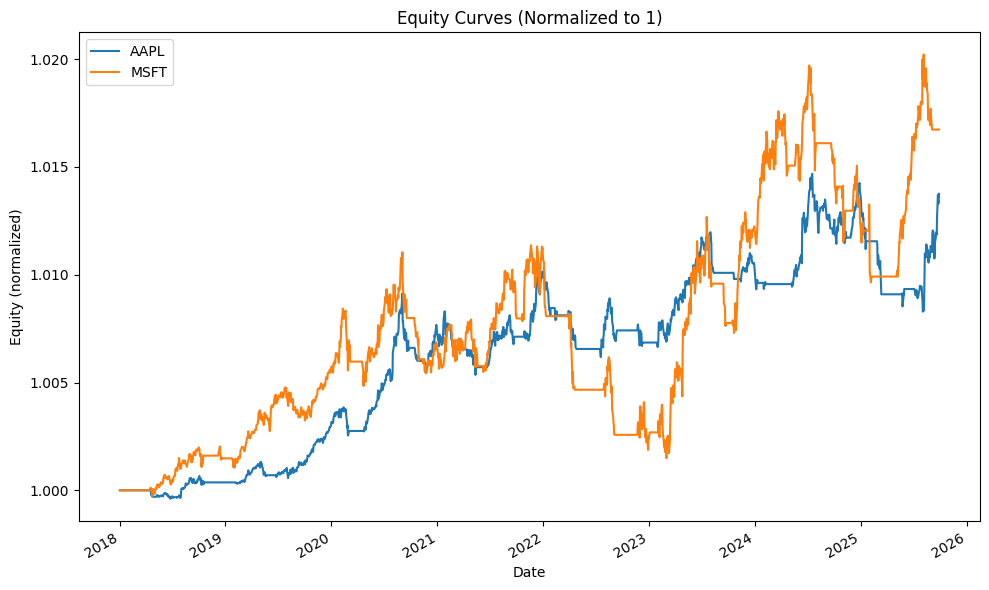

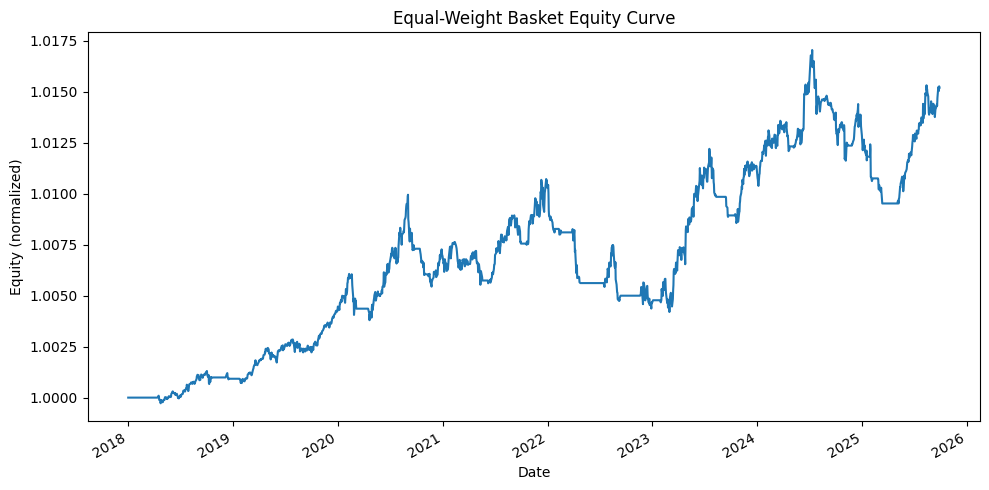

In [ ]:

import datetime as dt
from dataclasses import dataclass
from typing import List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import backtrader as bt
import yfinance as yf

# =========================
# ====== CONFIG HERE ======
# =========================
CONFIG = {
    # Universe & data
    "TICKERS": ["AAPL", "MSFT"],          # e.g., ["BTC-USD","ETH-USD"]
    "START": "2018-01-01",
    "END": dt.date.today().isoformat(),

    # Broker & costs
    "CASH": 10_000.0,
    "COMMISSION": 0.001,                  # 0.1% per trade
    "STAKE": 1,                           # fixed size per trade (units/shares/contracts)

    # Strategy core
    "FAST": 10,
    "SLOW": 50,

    # Filters (toggle True/False)
    "USE_RSI": False,
    "RSI_PERIOD": 14,
    "RSI_BUY": 30,
    "RSI_SELL": 70,

    "USE_MACD": False,

    # Risk control
    "TRAILING_STOP": False,
    "TRAIL_PERC": 0.05,                   # 5% trailing stop

    # Output
    "PRINTLOG": False,
    "SHOW_PLOTS": True
}

# =========================
# ====== STRATEGY =========
# =========================
class SMACrossWithFilters(bt.Strategy):
    params = dict(
        fast=10,
        slow=50,
        use_rsi=False,
        rsi_period=14,
        rsi_buy=30,
        rsi_sell=70,
        use_macd=False,
        trailing_stop=False,
        trail_perc=0.05,
        stake=1,
        printlog=False,
    )

    def log(self, txt):
        if self.p.printlog:
            dtstr = self.datas[0].datetime.date(0).isoformat()
            print(f"{dtstr} - {txt}")

    def __init__(self):
        d = self.datas[0]
        self.sma_fast = bt.ind.SMA(d.close, period=self.p.fast)
        self.sma_slow = bt.ind.SMA(d.close, period=self.p.slow)
        self.crossover = bt.ind.CrossOver(self.sma_fast, self.sma_slow)

        # Optional filters
        self.rsi = bt.ind.RSI(d.close, period=self.p.rsi_period)
        self.macd = bt.ind.MACD(d.close)  # macd.macd, macd.signal, macd.histo

        # Order refs
        self.order = None
        self.stop_order = None

    def cancel_stops(self):
        if self.stop_order:
            try:
                self.cancel(self.stop_order)
            except Exception:
                pass
            self.stop_order = None

    def notify_order(self, order):
        if order.status in [order.Submitted, order.Accepted]:
            return
        if order.status in [order.Completed]:
            side = "BUY" if order.isbuy() else "SELL"
            self.log(f"{side} EXECUTED @ {order.executed.price:.4f}")
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            self.log("Order Canceled/Margin/Rejected")
        self.order = None

    def next(self):
        if self.order:
            return  # wait for pending order

        # Filter states
        rsi_buy_ok = (self.rsi[0] < self.p.rsi_buy) if self.p.use_rsi else True
        rsi_sell_ok = (self.rsi[0] > self.p.rsi_sell) if self.p.use_rsi else True
        macd_buy_ok = (self.macd.macd[0] > 0) if self.p.use_macd else True
        macd_sell_ok = (self.macd.macd[0] < 0) if self.p.use_macd else True

        # Exit first: faster reaction to bearish cross
        if self.position:
            if self.crossover < 0 and macd_sell_ok and rsi_sell_ok:
                self.cancel_stops()
                self.order = self.sell(size=self.position.size)
                return

        # Entry
        if not self.position:
            if self.crossover > 0 and macd_buy_ok and rsi_buy_ok:
                self.order = self.buy(size=self.p.stake)
                if self.p.trailing_stop:
                    # StopTrail follows price upward
                    self.stop_order = self.sell(
                        exectype=bt.Order.StopTrail,
                        trailpercent=self.p.trail_perc,
                        size=self.p.stake
                    )

    def notify_trade(self, trade):
        if trade.isclosed:
            self.log(f"TRADE PnL: GROSS {trade.pnl:.2f}, NET {trade.pnlcomm:.2f}")

# =========================
# ====== HELPERS ==========
# =========================
def download_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    yfinance sometimes returns MultiIndex columns (tuples).
    We force single-level OHLCV and lower-case names for Backtrader.
    """
    df = yf.download(
        ticker,
        start=start,
        end=end,
        auto_adjust=True,      # adjusted OHLC
        progress=False,
        group_by="column"      # <- critical to avoid MultiIndex like ('Adj Close', '')
    )
    if df.empty:
        raise ValueError(f"No data for {ticker} in range {start} to {end}.")

    # Flatten if MultiIndex sneaks in
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Keep only columns expected by PandasData (we'll pass lowercase)
    cols = [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
    if not cols:
        raise ValueError(f"Downloaded data for {ticker} has unexpected columns: {df.columns.tolist()}")

    df = df[cols].copy()
    df.columns = [c.lower() for c in df.columns]  # open, high, low, close, volume
    df.dropna(inplace=True)
    df.sort_index(inplace=True)
    # Ensure datetime index (no tz)
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    df.index = df.index.tz_localize(None)
    return df

def to_bt_feed(df: pd.DataFrame) -> bt.feeds.PandasData:
    df = df.copy()
    df.index.name = "datetime"
    # Map lowercase column names to Backtrader fields explicitly (robust)
    return bt.feeds.PandasData(
        dataname=df,
        datetime=None,
        open='open',
        high='high',
        low='low',
        close='close',
        volume='volume',
        openinterest=None
    )

@dataclass
class BacktestResult:
    ticker: str
    cumulative_return: float
    max_drawdown: float
    sharpe: float
    daily_returns: pd.Series
    equity_curve: pd.Series

def run_single_backtest(
    ticker: str,
    start: str,
    end: str,
    cash: float,
    commission: float,
    fast: int,
    slow: int,
    use_rsi: bool,
    rsi_period: int,
    rsi_buy: int,
    rsi_sell: int,
    use_macd: bool,
    trailing_stop: bool,
    trail_perc: float,
    stake: int,
    printlog: bool,
) -> BacktestResult:

    df = download_data(ticker, start, end)
    data = to_bt_feed(df)

    cerebro = bt.Cerebro(stdstats=False)
    cerebro.adddata(data, name=ticker)
    cerebro.broker.setcash(cash)
    cerebro.broker.setcommission(commission=commission)
    cerebro.addsizer(bt.sizers.SizerFix, stake=stake)

    cerebro.addstrategy(
        SMACrossWithFilters,
        fast=fast,
        slow=slow,
        use_rsi=use_rsi,
        rsi_period=rsi_period,
        rsi_buy=rsi_buy,
        rsi_sell=rsi_sell,
        use_macd=use_macd,
        trailing_stop=trailing_stop,
        trail_perc=trail_perc,
        stake=stake,
        printlog=printlog,
    )

    # Analyzers
    cerebro.addanalyzer(bt.analyzers.TimeReturn, timeframe=bt.TimeFrame.Days, _name="timereturn")
    cerebro.addanalyzer(bt.analyzers.SharpeRatio, timeframe=bt.TimeFrame.Days, riskfreerate=0.0, _name="sharpe")
    cerebro.addanalyzer(bt.analyzers.DrawDown, _name="drawdown")

    results = cerebro.run()
    strat = results[0]

    daily_rets = pd.Series(strat.analyzers.timereturn.get_analysis())
    if not daily_rets.empty:
        daily_rets.index = pd.to_datetime(daily_rets.index)

    equity_curve = (1 + daily_rets.fillna(0)).cumprod() if not daily_rets.empty else pd.Series(dtype=float)

    sharpe = strat.analyzers.sharpe.get_analysis().get("sharperatio", np.nan)
    dd = strat.analyzers.drawdown.get_analysis()
    max_dd = dd.get("max", {}).get("drawdown", np.nan) / 100.0  # convert % to fraction

    cumret = equity_curve.iloc[-1] - 1.0 if not equity_curve.empty else 0.0

    return BacktestResult(
        ticker=ticker,
        cumulative_return=float(cumret),
        max_drawdown=float(max_dd),
        sharpe=float(sharpe) if sharpe is not None else np.nan,
        daily_returns=daily_rets,
        equity_curve=equity_curve,
    )

def summarize_results(results: List[BacktestResult]) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append({
            "Ticker": r.ticker,
            "Cumulative Return": r.cumulative_return,
            "Max Drawdown": r.max_drawdown,
            "Sharpe (daily)": r.sharpe,
        })
    df = pd.DataFrame(rows).set_index("Ticker")
    return df.sort_values("Cumulative Return", ascending=False)

def plot_equity_curves(results: List[BacktestResult], title: str = "Equity Curves (Normalized to 1)"):
    if not results:
        return
    plt.figure(figsize=(10, 6))
    for r in results:
        if not r.equity_curve.empty:
            r.equity_curve.plot(label=r.ticker)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity (normalized)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# ========= RUN ===========
# =========================
def run_all(config: dict):
    results: List[BacktestResult] = []
    for tkr in config["TICKERS"]:
        r = run_single_backtest(
            ticker=tkr,
            start=config["START"],
            end=config["END"],
            cash=config["CASH"],
            commission=config["COMMISSION"],
            fast=config["FAST"],
            slow=config["SLOW"],
            use_rsi=config["USE_RSI"],
            rsi_period=config["RSI_PERIOD"],
            rsi_buy=config["RSI_BUY"],
            rsi_sell=config["RSI_SELL"],
            use_macd=config["USE_MACD"],
            trailing_stop=config["TRAILING_STOP"],
            trail_perc=config["TRAIL_PERC"],
            stake=config["STAKE"],
            printlog=config["PRINTLOG"],
        )
        results.append(r)

    summary = summarize_results(results)
    print("\n========== Backtest Summary ==========")
    to_show = summary.copy()
    to_show["Cumulative Return"] = (to_show["Cumulative Return"] * 100).map(lambda x: f"{x:.2f}%")
    to_show["Max Drawdown"] = (to_show["Max Drawdown"] * 100).map(lambda x: f"{x:.2f}%")
    to_show["Sharpe (daily)"] = to_show["Sharpe (daily)"].map(lambda x: f"{x:.2f}")
    print(to_show.to_string())

    if config["SHOW_PLOTS"]:
        plot_equity_curves(results)

        # Equal-weight basket (if multiple tickers)
        aligned = pd.DataFrame({r.ticker: r.daily_returns for r in results}).sort_index().fillna(0.0)
        if aligned.shape[1] > 1:
            ew_daily = aligned.mean(axis=1)
            ew_equity = (1 + ew_daily).cumprod()
            plt.figure(figsize=(10, 5))
            ew_equity.plot()
            plt.title("Equal-Weight Basket Equity Curve")
            plt.xlabel("Date")
            plt.ylabel("Equity (normalized)")
            plt.tight_layout()
            plt.show()

# Execute
if __name__ == "__main__":
    run_all(CONFIG)
